In [1]:
import os
import numpy as np
import pandas as pd
from lightgbm import LGBMRegressor
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import KBinsDiscretizer
import shap
import networkx as nx
import matplotlib.pyplot as plt


c:\Users\leoco\Documents\cours\M2_MOSEF\ML_theory\land_value_prediction\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
print(os.getcwd())
os.chdir("../")
os.getcwd()

c:\Users\leoco\Documents\cours\M2_MOSEF\ML_theory\land_value_prediction\notebooks


'c:\\Users\\leoco\\Documents\\cours\\M2_MOSEF\\ML_theory\\land_value_prediction'

In [3]:
df_test = pd.read_parquet(r"data\processed\train_test_out_sample_cleaned\idf_vf_test_cleaned.parquet")
df_train = pd.read_parquet(r"data\processed\train_test_out_sample_cleaned\idf_vf_train_cleaned.parquet")
df_full = pd.concat([df_train, df_test])

In [4]:
cols_to_remove = ['prix_m2', 'ecart_prix_median_pct', 'is_maison', 'nord_paris', 'est_paris']

X = df_full.drop(columns=cols_to_remove)
y = df_full['prix_m2']

print(f"Dataset: {X.shape[0]:,} échantillons, {X.shape[1]} features")
print(f"Target (prix_m2): min={y.min():.0f}, max={y.max():.0f}, médiane={y.median():.0f}")

Dataset: 634,236 échantillons, 103 features
Target (prix_m2): min=1500, max=15000, médiane=4762


In [5]:
# Créer 10 bins pour stratification
n_bins = 10
binner = KBinsDiscretizer(n_bins=n_bins, encode='ordinal', strategy='quantile')
y_binned = binner.fit_transform(y.values.reshape(-1, 1)).ravel().astype(int)

# Vérifier la distribution
print(f"Target divisée en {n_bins} bins (quantiles)")
bin_counts = pd.Series(y_binned).value_counts().sort_index()
print("Distribution des bins:")
for bin_idx, count in bin_counts.items():
    print(f"   Bin {int(bin_idx)}: {count:>6} échantillons ({count/len(y)*100:>5.1f}%)")

Target divisée en 10 bins (quantiles)
Distribution des bins:
   Bin 0:  63233 échantillons ( 10.0%)
   Bin 1:  63958 échantillons ( 10.1%)
   Bin 2:  63374 échantillons ( 10.0%)
   Bin 3:  62734 échantillons (  9.9%)
   Bin 4:  63313 échantillons ( 10.0%)
   Bin 5:  62979 échantillons (  9.9%)
   Bin 6:  63532 échantillons ( 10.0%)
   Bin 7:  63967 échantillons ( 10.1%)
   Bin 8:  63474 échantillons ( 10.0%)
   Bin 9:  63672 échantillons ( 10.0%)


c:\Users\leoco\Documents\cours\M2_MOSEF\ML_theory\land_value_prediction\.venv\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


In [6]:
def compute_shap_results(X, y, y_binned, n_bins=10, n_folds=5):
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
    shap_results = []

    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X, y_binned), 1):
        print(f" FOLD {fold_idx}/{n_folds}")

        X_fold = X.iloc[train_idx]
        y_fold = y.iloc[train_idx]

        y_fold_stats = {
            'min': y_fold.min(),
            'q25': y_fold.quantile(0.25),
            'median': y_fold.median(),
            'q75': y_fold.quantile(0.75),
            'max': y_fold.max()
        }
        print(f"   Train: {len(train_idx):,} échantillons")
        print(f"   Val:   {len(val_idx):,} échantillons")
        print(f"   Target train: min={y_fold_stats['min']:.0f}, "
              f"Q25={y_fold_stats['q25']:.0f}, "
              f"med={y_fold_stats['median']:.0f}, "
              f"Q75={y_fold_stats['q75']:.0f}, "
              f"max={y_fold_stats['max']:.0f}")

        lgbm = LGBMRegressor(
            n_estimators=150,
            max_depth=8,
            learning_rate=0.05,
            num_leaves=31,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42 + fold_idx,
            verbose=-1,
            n_jobs=-1
        )
        lgbm.fit(X_fold, y_fold)

        sample_size = min(1000, len(X_fold))
        sample_indices = []
        y_fold_binned = binner.transform(y_fold.values.reshape(-1, 1)).ravel().astype(int)
        for bin_val in range(n_bins):
            bin_indices = np.where(y_fold_binned == bin_val)[0]
            n_samples_bin = int(sample_size / n_bins)
            if len(bin_indices) > 0:
                sampled = np.random.choice(bin_indices,
                                          size=min(n_samples_bin, len(bin_indices)),
                                          replace=False)
                sample_indices.extend(sampled)

        X_sample = X_fold.iloc[sample_indices]
        explainer = shap.TreeExplainer(lgbm)
        shap_values = explainer.shap_values(X_sample)
        mean_abs_shap = np.abs(shap_values).mean(axis=0)

        shap_results.append({
            'fold': fold_idx,
            'shap_values': mean_abs_shap,
            'feature_names': X.columns.tolist()
        })
    return shap_results

shap_results = compute_shap_results(X, y, y_binned, n_bins=n_bins, n_folds=5)

 FOLD 1/5
   Train: 507,388 échantillons
   Val:   126,848 échantillons
   Target train: min=1500, Q25=3308, med=4762, Q75=8000, max=15000
 FOLD 2/5
   Train: 507,389 échantillons
   Val:   126,847 échantillons
   Target train: min=1500, Q25=3308, med=4762, Q75=8000, max=15000
 FOLD 3/5
   Train: 507,389 échantillons
   Val:   126,847 échantillons
   Target train: min=1500, Q25=3308, med=4762, Q75=8000, max=15000
 FOLD 4/5
   Train: 507,389 échantillons
   Val:   126,847 échantillons
   Target train: min=1500, Q25=3308, med=4762, Q75=8000, max=15000
 FOLD 5/5
   Train: 507,389 échantillons
   Val:   126,847 échantillons
   Target train: min=1500, Q25=3307, med=4762, Q75=8000, max=15000


In [7]:
def compute_shap_summary(shap_results, X):
    shap_matrix = np.array([result['shap_values'] for result in shap_results])
    shap_mean = shap_matrix.mean(axis=0)
    shap_std = shap_matrix.std(axis=0)

    results_df = pd.DataFrame({
        'feature': X.columns,
        'shap_mean': shap_mean,
        'shap_std': shap_std
    })

    # Normaliser les scores (0-100)
    results_df['shap_norm'] = (results_df['shap_mean'] - results_df['shap_mean'].min()) / \
                              (results_df['shap_mean'].max() - results_df['shap_mean'].min()) * 100

    # Trier par score combiné
    results_df = results_df.sort_values('shap_norm', ascending=False)

    return results_df[['feature', 'shap_mean', 'shap_norm']]

results_df = compute_shap_summary(shap_results, X)
results_df

,feature,shap_mean,shap_norm
3,prix_m2_median_maisons_voisines,1317.223629,100.000000
92,ratio_terrain_bati,314.385585,23.865750
25,commune_education_score_2013_commune,233.362697,17.714590
90,densite_rel_2000m,225.005324,17.080109
101,surface_x_type,222.121257,16.861154
...,...,...,...
36,Evolution_PIB_volume_en_%_base2020_lag3t,0.160864,0.010190
48,nb_commerce_500m,0.144391,0.008939
62,nb_transport_autre_500m,0.100161,0.005581
52,nb_sante_500m,0.097387,0.005370


On ne garde que les variables pour lesquelles la valeur de shapley est supérieure à 1% de la valeur de Shapley maximum. 

In [8]:
selected_features = results_df[results_df["shap_norm"] > 1]["feature"].tolist()
print(f"On ne garde que {len(selected_features)} features avec un SHAP normalisé > 1")
print(f"Ce sont les features suivantes: {selected_features}")

On ne garde que 31 features avec un SHAP normalisé > 1
Ce sont les features suivantes: ['prix_m2_median_maisons_voisines', 'ratio_terrain_bati', 'commune_education_score_2013_commune', 'densite_rel_2000m', 'surface_x_type', 'nombre_lots', 'nb_transport_autre_2000m', 'commune_part_commerce_tourisme', 'is_appartement', 'log_surface_bati', 'distance_paris', 'commune_densite_residences_principales_2020', 'densite_lots', 'commune_revenu_median_2020', 'nb_jours_depuis_janvier_2021', 'commune_etablissements_1_salarie_2021', 'Taux_moyen_credit_immo_lag3t', 'prix_median_x_distance', 'commune_ratio_residences_secondaires_population', 'commune_idh2_2013_commune', 'surface_par_piece', 'Taux_moyen_credit_immo_lag1t', 'surface_terrain', 'dist_transport_lourd', 'commune_taux_proprietaires', 'Evolution_PIB_volume_en_%_base2020_lag4t', 'nb_services_2000m', 'nb_loisirs_2000m', 'nombre_pieces_principales', 'nb_education_2000m', 'dist_transport_autre']


In [9]:
df_with_selected_features = df_full[selected_features + ['prix_m2']]
df_with_selected_features

,prix_m2_median_maisons_voisines,ratio_terrain_bati,commune_education_score_2013_commune,densite_rel_2000m,surface_x_type,nombre_lots,nb_transport_autre_2000m,commune_part_commerce_tourisme,is_appartement,log_surface_bati,...,surface_terrain,dist_transport_lourd,commune_taux_proprietaires,Evolution_PIB_volume_en_%_base2020_lag4t,nb_services_2000m,nb_loisirs_2000m,nombre_pieces_principales,nb_education_2000m,dist_transport_autre,prix_m2
0,9782.608398,0.000000,0.902589,1.355828,160,1,27,0.848215,1,4.394449,...,0.0,268.899414,0.325563,0.193834,17,290,3,122,292.677704,7750.000000
1,5606.589355,0.000000,0.451268,0.241548,52,1,4,0.643595,1,3.295837,...,0.0,319.581665,0.282208,0.900489,8,235,2,56,278.497620,4500.000000
2,3152.272705,0.000000,0.636588,-1.289530,101,1,2,0.600000,0,4.624973,...,0.0,1018.376892,0.811383,0.506923,2,33,5,2,1001.495361,2623.762451
3,10938.690430,0.000000,0.824937,2.088961,36,1,31,0.852084,1,2.944439,...,0.0,272.015564,0.370956,15.361810,17,307,1,185,241.933548,12111.111328
4,5555.555664,1.843374,0.650801,0.010234,83,0,1,0.773960,0,4.430817,...,153.0,992.912659,0.483656,15.361810,3,228,5,33,1222.034424,8192.771484
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
126843,3795.454590,1.735294,0.685132,-0.590734,34,0,1,0.701299,0,3.555348,...,59.0,658.067627,0.649225,0.399707,5,161,2,13,621.508301,4289.706055
126844,10100.000000,0.000000,0.865192,0.427209,44,1,6,0.804709,1,3.135494,...,0.0,29.374443,0.478174,0.559991,7,291,1,51,867.653931,10000.000000
126845,3167.094727,0.000000,0.469415,-1.289505,94,1,1,0.683168,0,4.553877,...,0.0,533.554138,0.697908,2.991206,4,47,5,1,520.911987,2340.425537
126846,5956.410156,0.000000,0.410136,0.903930,80,1,5,0.703074,1,3.713572,...,0.0,405.890564,0.322951,-12.214629,10,275,2,59,976.805115,4950.000000


On doit maintenant procéder à une nouvelle analyse des corrélations présentes dans le dataframe :

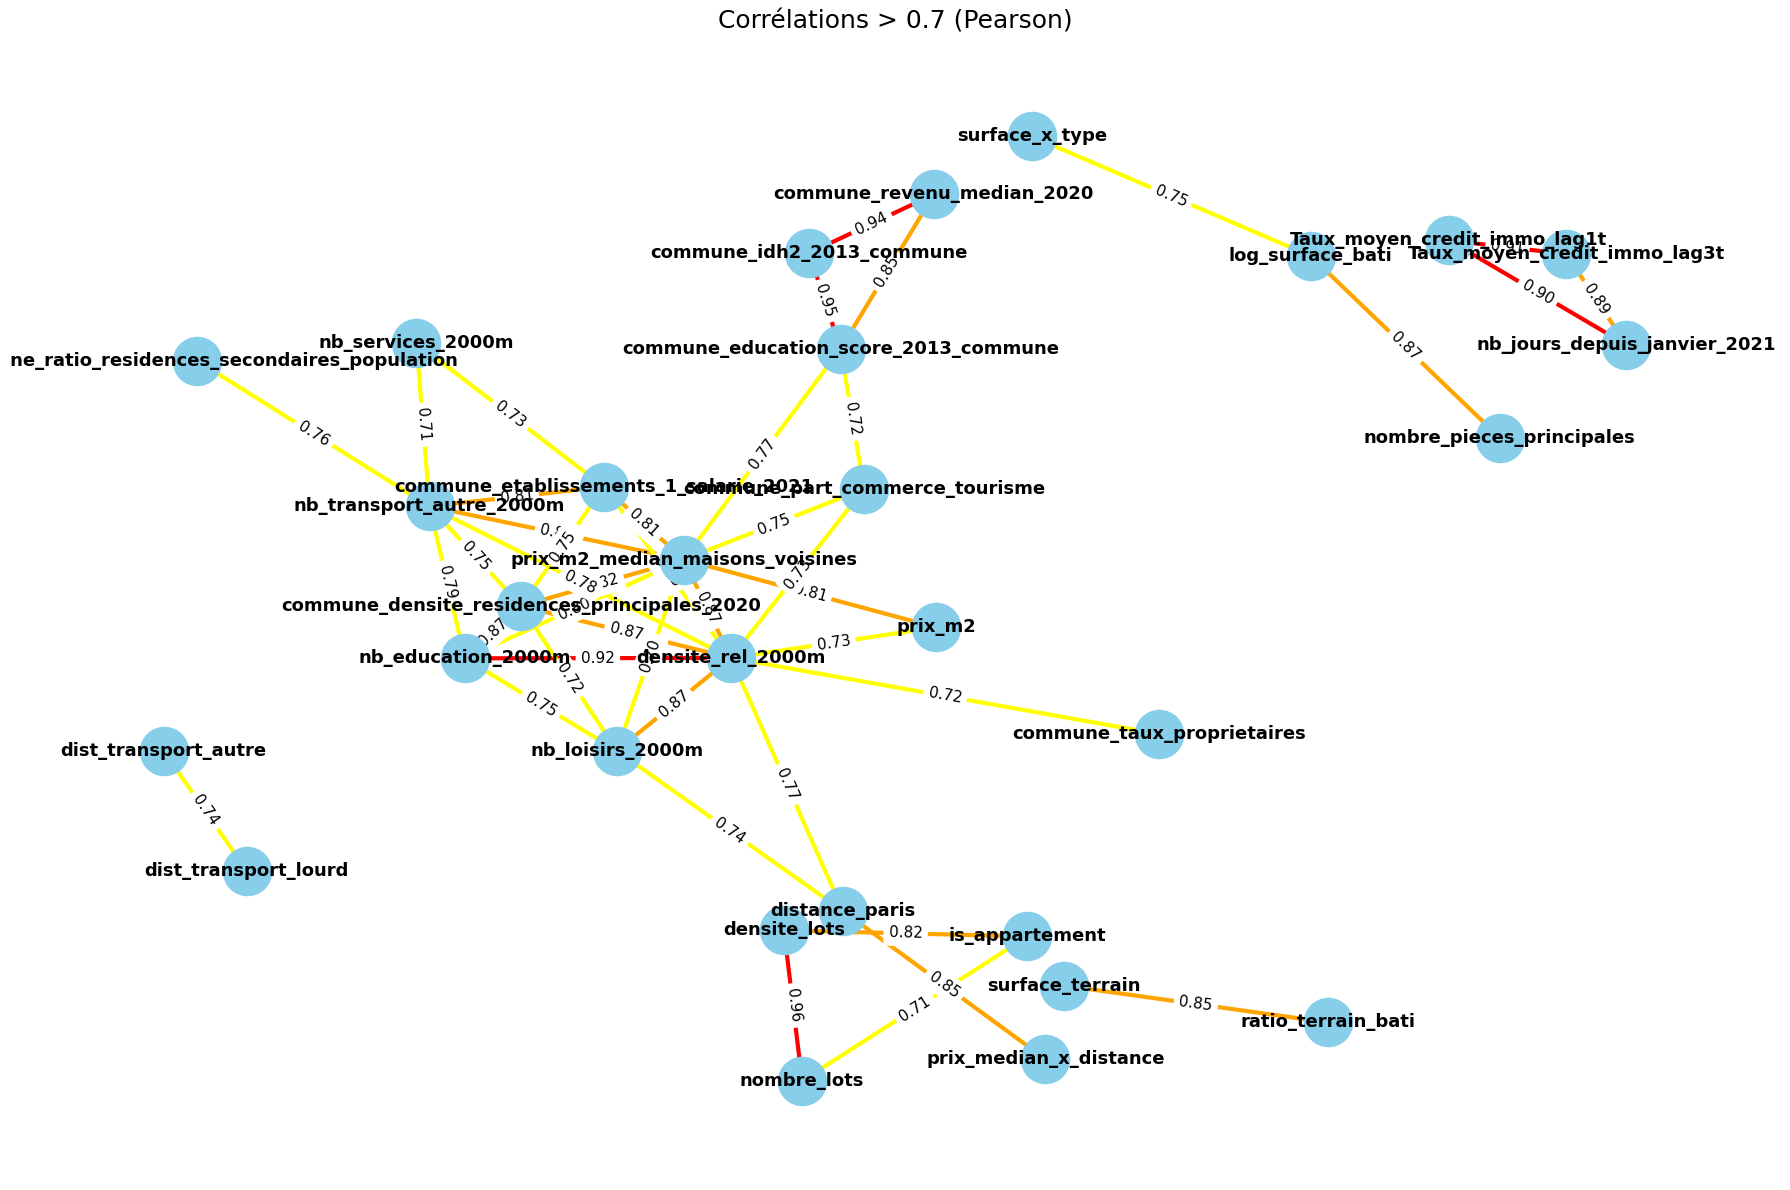

In [10]:
def plot_strong_correlations(df, threshold=0.7, figsize=(18, 12), seed=42):
    corr_matrix = df.corr(method='pearson').abs()
    strong_corr = (corr_matrix > threshold) & (corr_matrix < 1.0)
    edges = [(i, j, corr_matrix.loc[i, j]) 
             for i in corr_matrix.columns 
             for j in corr_matrix.columns 
             if strong_corr.loc[i, j]]

    G = nx.Graph()
    for i, j, w in edges:
        G.add_edge(i, j, weight=w)

    edge_colors = []
    for u, v in G.edges():
        w = G[u][v]['weight']
        if threshold < w <= 0.8:
            edge_colors.append('yellow')
        elif 0.8 < w <= 0.9:
            edge_colors.append('orange')
        elif w > 0.9:
            edge_colors.append('red')
        else:
            edge_colors.append('grey')

    plt.figure(figsize=figsize)
    pos = nx.spring_layout(G, k=0.6, seed=seed)
    nx.draw_networkx_nodes(G, pos, node_size=1200, node_color="#87CEEB")
    nx.draw_networkx_edges(G, pos, edge_color=edge_colors, width=3)
    nx.draw_networkx_labels(G, pos, font_size=13, font_weight='bold')
    edge_labels = {(u, v): f"{G[u][v]['weight']:.2f}" for u, v in G.edges()}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='black', font_size=11)
    plt.title(f"Corrélations > {threshold} (Pearson)", fontsize=18)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

plot_strong_correlations(df_with_selected_features, threshold=0.7)


A partir de cette annalyse on va enlever quelques variables, on garde à chaque fois la variable qui a la plus grande valeur de shapley:

In [11]:
correlated_features_to_drop = ["surface_terrain",
                               "densite_lots", 
                               "nombre_pieces_principales",
                               "Taux_moyen_credit_immo_lag3t", 
                               "nb_jours_depuis_janvier_2021", # cette variable ne fait pas sens
                               "nb_education_2000m", 
                               "commune_idh2_2013_commune", 
                               "prix_median_x_distance"
                               ]

df_with_selected_features = df_with_selected_features.drop(columns=correlated_features_to_drop, errors='ignore')
df_with_selected_features

,prix_m2_median_maisons_voisines,ratio_terrain_bati,commune_education_score_2013_commune,densite_rel_2000m,surface_x_type,nombre_lots,nb_transport_autre_2000m,commune_part_commerce_tourisme,is_appartement,log_surface_bati,...,commune_ratio_residences_secondaires_population,surface_par_piece,Taux_moyen_credit_immo_lag1t,dist_transport_lourd,commune_taux_proprietaires,Evolution_PIB_volume_en_%_base2020_lag4t,nb_services_2000m,nb_loisirs_2000m,dist_transport_autre,prix_m2
0,9782.608398,0.000000,0.902589,1.355828,160,1,27,0.848215,1,4.394449,...,0.095065,26.666666,0.0373,268.899414,0.325563,0.193834,17,290,292.677704,7750.000000
1,5606.589355,0.000000,0.451268,0.241548,52,1,4,0.643595,1,3.295837,...,0.013689,13.000000,0.0399,319.581665,0.282208,0.900489,8,235,278.497620,4500.000000
2,3152.272705,0.000000,0.636588,-1.289530,101,1,2,0.600000,0,4.624973,...,0.014819,20.200001,0.0329,1018.376892,0.811383,0.506923,2,33,1001.495361,2623.762451
3,10938.690430,0.000000,0.824937,2.088961,36,1,31,0.852084,1,2.944439,...,0.093602,18.000000,0.0106,272.015564,0.370956,15.361810,17,307,241.933548,12111.111328
4,5555.555664,1.843374,0.650801,0.010234,83,0,1,0.773960,0,4.430817,...,0.016016,16.600000,0.0106,992.912659,0.483656,15.361810,3,228,1222.034424,8192.771484
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
126843,3795.454590,1.735294,0.685132,-0.590734,34,0,1,0.701299,0,3.555348,...,0.008432,17.000000,0.0105,658.067627,0.649225,0.399707,5,161,621.508301,4289.706055
126844,10100.000000,0.000000,0.865192,0.427209,44,1,6,0.804709,1,3.135494,...,0.036750,22.000000,0.0178,29.374443,0.478174,0.559991,7,291,867.653931,10000.000000
126845,3167.094727,0.000000,0.469415,-1.289505,94,1,1,0.683168,0,4.553877,...,0.109685,18.799999,0.0140,533.554138,0.697908,2.991206,4,47,520.911987,2340.425537
126846,5956.410156,0.000000,0.410136,0.903930,80,1,5,0.703074,1,3.713572,...,0.007103,20.000000,0.0113,405.890564,0.322951,-12.214629,10,275,976.805115,4950.000000


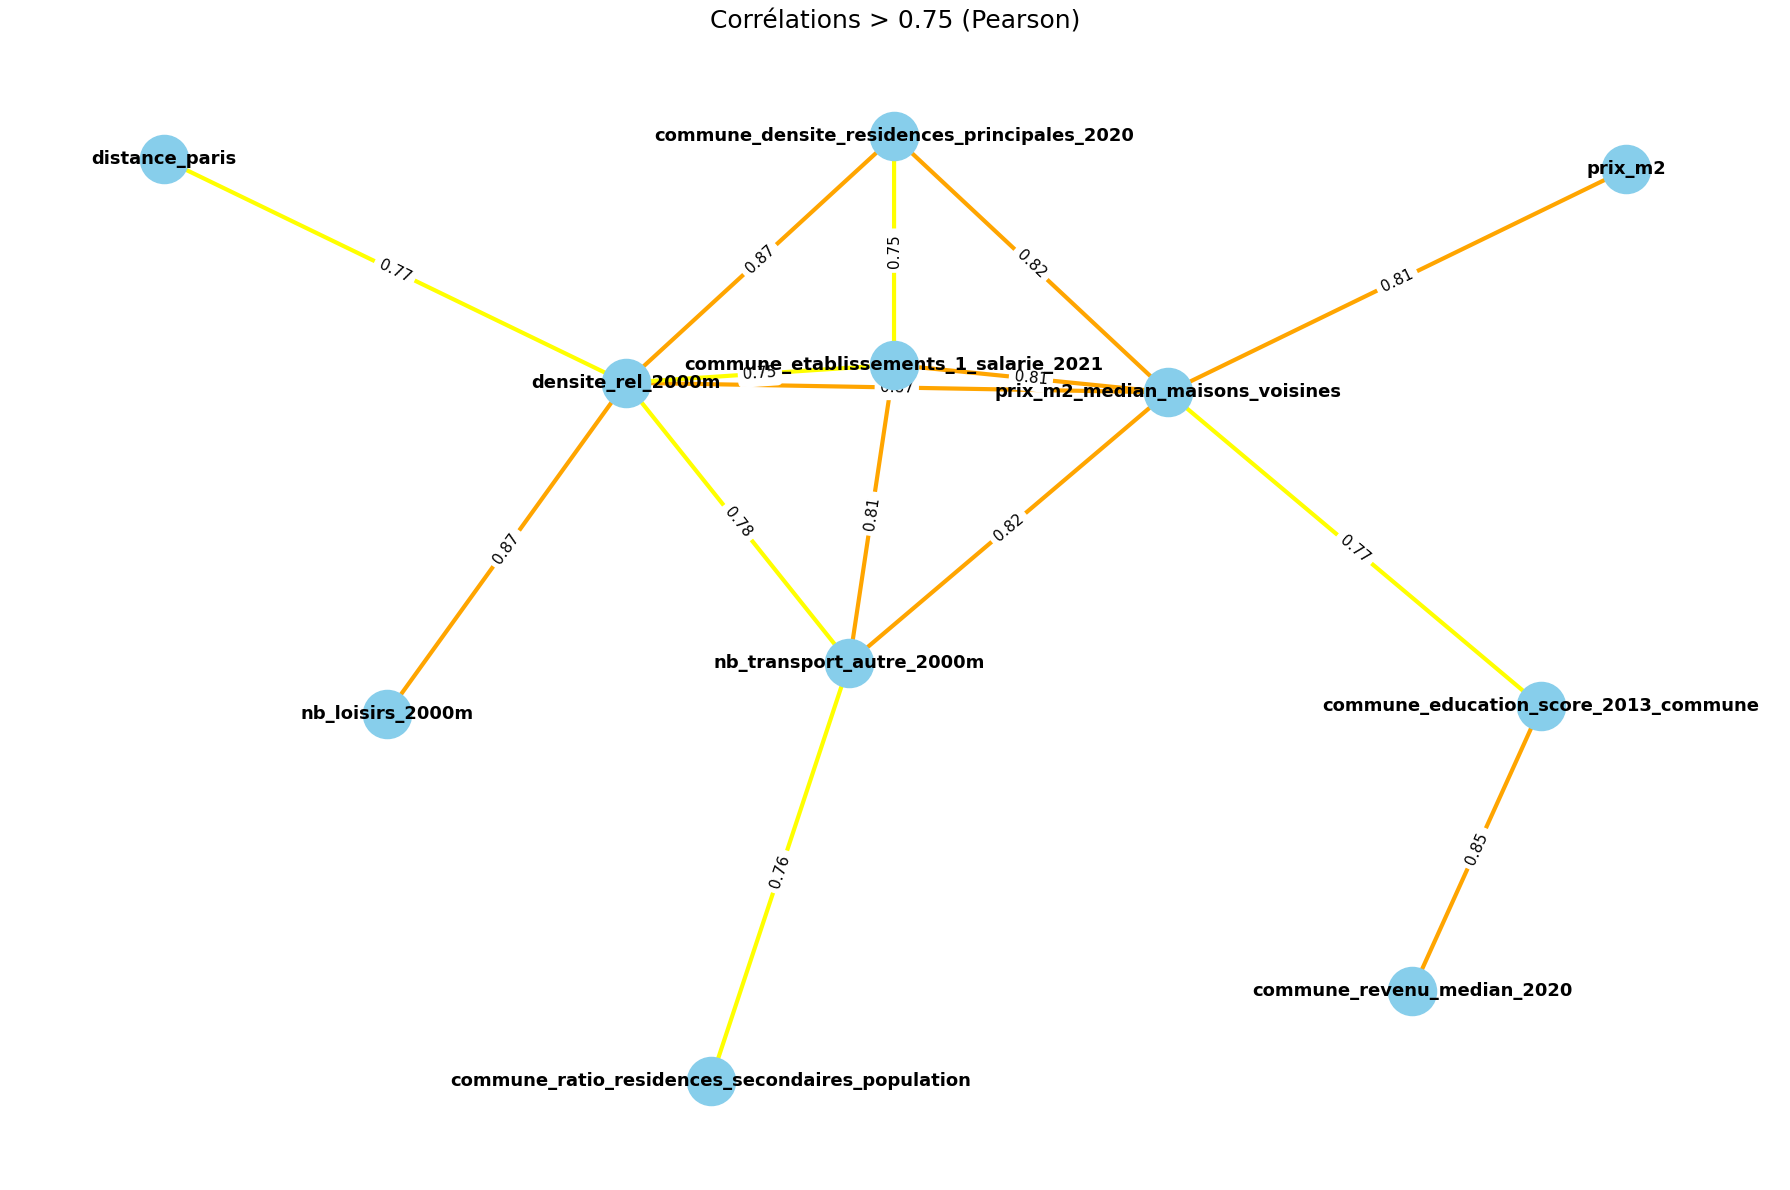

In [12]:
plot_strong_correlations(df_with_selected_features, threshold=0.75)

Pour des modèles d'arbre ce n'est pas très grave pour la performance du modèle d'avoir des corrélations. Donc pour l'instant on garde le dataframe tel quel. Pour mieux comprendre les drivers du prix au mètre carré il faudra enlever le prix médian du metre carré des maisons voisines. 

Appliquer la selection à l'échantillon OOT :

In [18]:
oos_df = pd.read_parquet(r"data/processed/train_test_out_sample_cleaned/idf_vf_out_of_sample_cleaned.parquet")
oos_df = oos_df[selected_features + ["prix_m2"]]
oos_df = oos_df.drop(columns=correlated_features_to_drop, errors='ignore')
oos_df

,prix_m2_median_maisons_voisines,ratio_terrain_bati,commune_education_score_2013_commune,densite_rel_2000m,surface_x_type,nombre_lots,nb_transport_autre_2000m,commune_part_commerce_tourisme,is_appartement,log_surface_bati,...,commune_ratio_residences_secondaires_population,surface_par_piece,Taux_moyen_credit_immo_lag1t,dist_transport_lourd,commune_taux_proprietaires,Evolution_PIB_volume_en_%_base2020_lag4t,nb_services_2000m,nb_loisirs_2000m,dist_transport_autre,prix_m2
0,4005.208252,0.000000,0.400966,0.003226,144,1,2,0.635346,1,4.290460,...,0.010006,24.000000,0.0338,134.432617,0.372387,0.144057,8,255,1561.106567,3097.222168
1,3682.135010,0.000000,0.610739,-0.832668,156,2,0,0.823000,1,4.369448,...,0.036247,19.500000,0.0338,135.523117,0.409828,0.144057,7,72,2138.718506,3551.281982
2,5482.353027,0.000000,0.889821,-0.042039,30,1,0,0.810565,1,2.772589,...,0.026782,15.000000,0.0338,145.372406,0.477340,0.144057,2,174,2997.037598,8000.000000
3,8277.418945,0.000000,0.835437,0.742554,124,1,5,0.834500,1,4.143135,...,0.054721,20.666666,0.0338,622.195190,0.422396,0.144057,6,314,813.115479,7658.467773
4,2683.333252,0.000000,0.389963,-0.651608,204,1,1,0.659074,1,4.634729,...,0.004541,20.400000,0.0338,1174.676025,0.391079,0.144057,8,127,1987.734741,1980.392212
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47763,3621.912109,3.026316,0.523603,-1.089169,76,0,0,0.633484,0,4.343805,...,0.005232,19.000000,0.0316,2226.469971,0.649097,0.191300,2,94,2205.192871,3723.684326
47764,3579.545410,0.000000,0.473365,-0.129552,184,1,0,0.619617,1,4.532599,...,0.009441,23.000000,0.0316,1345.507935,0.650443,0.191300,6,213,2608.043457,1569.934814
47765,4420.212891,0.000000,0.682606,0.208427,120,1,2,0.755556,1,4.110874,...,0.044261,20.000000,0.0316,1653.855713,0.453915,0.191300,3,326,1812.403931,5000.000000
47766,4289.473633,3.674797,0.639937,-1.055975,123,0,1,0.637681,0,4.820282,...,0.004543,20.500000,0.0316,1396.173706,0.730947,0.191300,2,64,1426.948120,3869.918701


Export de la base :

In [19]:
df_with_selected_features.to_parquet(r"data/processed/selected_features/idf_vf_train_test_selected_features.parquet", index=False)
oos_df.to_parquet(r"data/processed/selected_features/idf_vf_out_of_sample_selected_features.parquet", index=False)